In [21]:
from pathlib import Path

ROOT = Path.cwd().resolve().parent

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f"{ROOT}/data/raw/customer_booking.csv", encoding = 'latin1')
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [93]:
df['booking_complete'].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [92]:
df_cleaned = df.drop_duplicates()
df_cleaned.shape
df_cleaned['booking_complete'].value_counts()

booking_complete
0    41890
1     7391
Name: count, dtype: int64

In [24]:
length_of_stay_threshold = df['length_of_stay'].quantile(0.98)
purchase_lead_threshold = df['purchase_lead'].quantile(0.98)

pre_clean_rows = len(df)
df = df[
    (df['purchase_lead']<=purchase_lead_threshold) & (df['length_of_stay']<=length_of_stay_threshold)
]

print(f"Data cleaned successfully. {round((pre_clean_rows-len(df))/pre_clean_rows, 4)*100}% of data; {pre_clean_rows-len(df)} rows removed.")

Data cleaned successfully. 3.94% of data; 1969 rows removed.


In [25]:
def target_encoding(smoothing_factor, DataFrame_train, DataFrame_test, columns, target):
    df_train = DataFrame_train.copy()
    df_test = DataFrame_test.copy()
    global_mean = df_train[target].mean()
    
    m = smoothing_factor 

    for column in columns:
        # Calculate smoothed means
        agg = df_train.groupby(column)[target].agg(['count', 'mean'])
        counts = agg['count']
        means = agg['mean']

        smooth_map = (counts * means + m * global_mean) / (counts + m)
        smooth_dict = smooth_map.to_dict()

        # Map and handle unseen categories in test
        df_train[f'{column}_encoded'] = df_train[column].map(smooth_dict)
        df_test[f'{column}_encoded'] = df_test[column].map(smooth_dict).fillna(global_mean)

    return df_train, df_test

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Step 1: Target Encoding for high-cardinality strings
# Step 2: One-Hot Encoding for low-cardinality strings (with specific drops)

preprocessor = ColumnTransformer(transformers=[
    # Target Encoding handles the complex 'Route' mapping
    ('target_enc', TargetEncoder(smooth=5), ['route', 'booking_origin', 'flight_day']),
    
    # One-Hot Encoding handles the high-value 'Trip Type'
    # We drop 'One Way' explicitly to keep 'Round Trip' and 'Circle Trip'
    ('one_hot', OneHotEncoder(
        categories=[['OneWay', 'RoundTrip', 'CircleTrip'], # trip_type categories
                    ['Mobile', 'Internet']],                  # sales_channel categories
        drop=['OneWay', 'Mobile'], 
        sparse_output=False
    ), ['trip_type', 'sales_channel'])
], remainder='passthrough')

rf_final = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Wrap in a Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_final)
])

In [47]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

X_train = df_train.drop(columns=['booking_complete'])
y_train = df_train['booking_complete']

X_train_preprocessed = preprocessor.fit_transform(X_train, y_train)

In [48]:
X_test = df_test.drop(columns=['booking_complete'])
y_test = df_test['booking_complete']

X_test_preprocessed = preprocessor.transform(X_test)

--- Final Test Results ---
Accuracy:  0.7042
ROC-AUC:   0.7902

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     12784
           1       0.30      0.75      0.43      2216

    accuracy                           0.70     15000
   macro avg       0.62      0.72      0.61     15000
weighted avg       0.85      0.70      0.75     15000


Confusion Matrix:
[[8898 3886]
 [ 551 1665]]


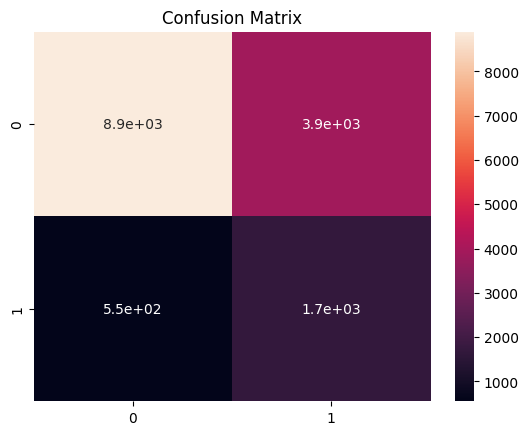

In [76]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_pipeline.fit(X_train, y_train)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_probs >= 0.3288).astype(int)

print("--- Final Test Results ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_threshold):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred_threshold)
print(conf_matrix)
sns.heatmap(conf_matrix, annot=True)
plt.title("Confusion Matrix")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)

target = 'booking_complete'
columns=['route', 'booking_origin', 'flight_day']
df_train, df_test = target_encoding(5, df_train, df_test, columns, target)

In [27]:
df_train.drop(columns=['route', 'booking_origin', 'flight_day'], inplace=True)
df_test.drop(columns=['route', 'booking_origin', 'flight_day'], inplace=True)

categorical_cols = [x for x in df_train.select_dtypes(include=['object'])]
print(categorical_cols)

df_train = pd.get_dummies(df_train, columns=categorical_cols, dtype='int')
df_test = pd.get_dummies(df_test, columns=categorical_cols, dtype='int')

df_train.drop(columns=['trip_type_OneWay', 'sales_channel_Mobile'], axis=1, inplace=True)
df_test.drop(columns=['trip_type_OneWay', 'sales_channel_Mobile'], axis=1, inplace=True)

['sales_channel', 'trip_type']


In [7]:
print(df_train.shape)
print(df_test.shape)

(33621, 15)
(14410, 15)


In [8]:
import os

OUTPUT_DIR = f"{ROOT}/data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(f'{OUTPUT_DIR}/df_cleaned.csv', index=False)
df_train.to_csv(f'{OUTPUT_DIR}/df_train.csv', index=False)
df_test.to_csv(f'{OUTPUT_DIR}/df_test.csv', index=False)

print(f"Successfully saved all files to: {OUTPUT_DIR}")

Successfully saved all files to: /home/zakir/projects_dir/mlproject/BA_DS_Task_2/british_airways_booking_predictor/data/processed
